# Biomechanica & Cadansanalyse (Batch) – Dataset B

Automatische extractie van de 'pacing rate' (Stappen Per Minuut, SPM) voor lopers. We filteren de medio-laterale schommeling van de head sway met een bandpass filter in SciPy en berekenen stappen cycli peak-to-peak. Deze analyse wordt uitgevoerd op basis van vooraf geëxtraheerde spatiotemporele data.

> **Vereisten:**
> - Detectiebestand `data/detecties/marathon.json`
>
> **Output:** Statistische samenvatting, Cadans Histogram plot en een gefilterde sway-grafiek.

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

print("Bibliotheken (incl. SciPy Signal Processing) succesvol geïmporteerd.")

# Pad naar je opgeslagen JSON detecties
JSON_PATH = '../../data/detecties/marathon.json'
MIN_TRACK_SECONDS = 1.5

print(f"Constanten geladen. Minimale tracking-tijd voor analyse: {MIN_TRACK_SECONDS} seconden.")

Bibliotheken (incl. SciPy Signal Processing) succesvol geïmporteerd.
Constanten geladen. Minimale tracking-tijd voor analyse: 1.5 seconden.


## Batch analyse van de stapfrequentie (Cadans)

In [6]:
print(f"Start met het laden van Y-Sway data uit: {JSON_PATH}...")

with open(JSON_PATH, 'r') as f:
    export_data = json.load(f)

fps = export_data["fps"]
runner_data = {}

# Zet de JSON data om naar het formaat dat de cadansanalyse verwacht
for t_id_str, track_info in export_data["tracks"].items():
    t_id = int(t_id_str)
    frames = track_info["frames"]
    y_coords = track_info["y_coords"]

    # Bereken timestamps direct op basis van de opgeslagen frames
    time_stamps = [frame / fps for frame in frames]

    runner_data[t_id] = {
        'y_coords': y_coords,
        'time_stamps': time_stamps
    }

low_cut = 0.8
high_cut = 2.0
nyquist = 0.5 * fps
b, a = butter(2, [low_cut / nyquist, high_cut / nyquist], btype='band', analog=False)

print("\n" + "="*60)
print("RESULTATEN: BIOMECHANISCHE STAPFREQUENTIE (SPM)")
print("="*60)

valid_spms = []
plot_data = {} # Opslag voor de sway-grafiek later
TARGET_ID_PLOT = 55 # Loper ID gekozen voor de thesis figuur

for t_id in sorted(runner_data.keys()):
    y_coords = runner_data[t_id]['y_coords']
    time_stamps = runner_data[t_id]['time_stamps']
    total_track_time = time_stamps[-1] - time_stamps[0]

    if total_track_time < MIN_TRACK_SECONDS or len(y_coords) <= 15:
        continue

    try:
        y_smoothed = filtfilt(b, a, y_coords)
        peaks, _ = find_peaks(y_smoothed, distance=fps*0.4)

        if len(peaks) > 1:
            tijd_eerste_piek = time_stamps[peaks[0]]
            tijd_laatste_piek = time_stamps[peaks[-1]]
            peak_to_peak_time = tijd_laatste_piek - tijd_eerste_piek

            if peak_to_peak_time > 0:
                aantal_intervallen = len(peaks) - 1
                aantal_stappen = aantal_intervallen * 2
                spm = (aantal_stappen / peak_to_peak_time) * 60

                if 80 <= spm <= 240:
                    valid_spms.append(spm)
                    if t_id == TARGET_ID_PLOT:
                        plot_data = {'time': time_stamps, 'smooth': y_smoothed, 'peaks': peaks, 'spm': spm}

    except ValueError:
        continue

if len(valid_spms) > 0:
    avg_spm = sum(valid_spms) / len(valid_spms)
    median_spm = np.median(valid_spms)
    print(f"STATISTISCHE SAMENVATTING STAPFREQUENTIE")
    print(f"Gemiddelde Cadans     : {avg_spm:.0f} SPM")
    print(f"Mediaan Cadans        : {median_spm:.0f} SPM")
    print(f"Aantal Lopers Gevat   : {len(valid_spms)}")
else:
    print("Geen lopers gevonden met een betrouwbare stapfrequentie.")
print("="*60)

Start met het laden van Y-Sway data uit: ../../data/detecties/marathon.json...

🏁 RESULTATEN: BIOMECHANISCHE STAPFREQUENTIE (SPM)
📊 STATISTISCHE SAMENVATTING STAPFREQUENTIE
Gemiddelde Cadans     : 163 SPM
Mediaan Cadans        : 164 SPM
Aantal Lopers Gevat   : 270


## Histogram Cadans

Start met het genereren van het cadanshistogram...


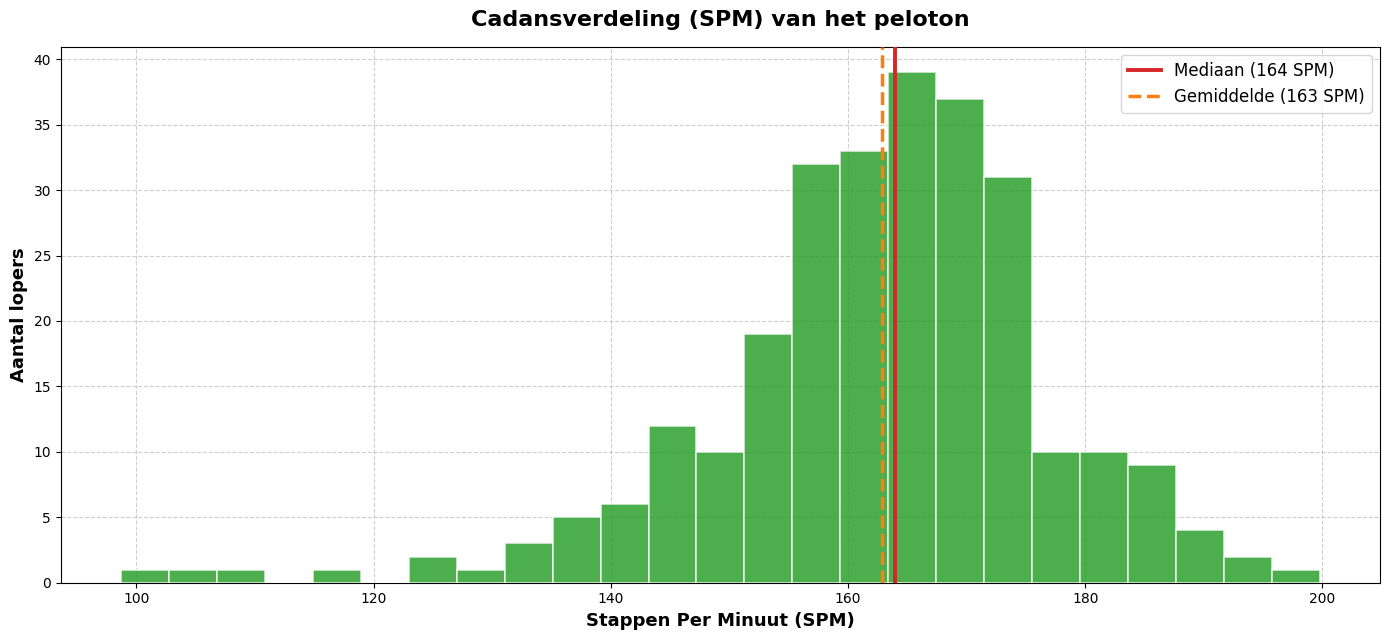

In [8]:
# ==============================================================================
# @title Cadans Histogram Genereren
# ==============================================================================

if len(valid_spms) > 0:
    print("Start met het genereren van het cadanshistogram...")

    spm_array = np.array(valid_spms)
    gemiddelde_spm = np.mean(spm_array)
    mediaan_spm = np.median(spm_array)

    plt.figure(figsize=(14, 6.5))
    n, bins, patches = plt.hist(spm_array, bins=25, color='#2ca02c', edgecolor='white',
                                linewidth=1.1, alpha=0.85, zorder=3)

    plt.axvline(mediaan_spm, color='#d62728', linewidth=2.8, linestyle='-', label=f'Mediaan ({mediaan_spm:.0f} SPM)', zorder=4)
    plt.axvline(gemiddelde_spm, color='#ff7f0e', linewidth=2.5, linestyle='--', label=f'Gemiddelde ({gemiddelde_spm:.0f} SPM)', zorder=4)

    plt.title("Cadansverdeling (SPM) van het peloton", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Stappen Per Minuut (SPM)", fontsize=13, fontweight='bold')
    plt.ylabel("Aantal lopers", fontsize=13, fontweight='bold')
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
    plt.tight_layout()
    plt.show()
else:
    print("Geen geldige data om een histogram te plotten.")

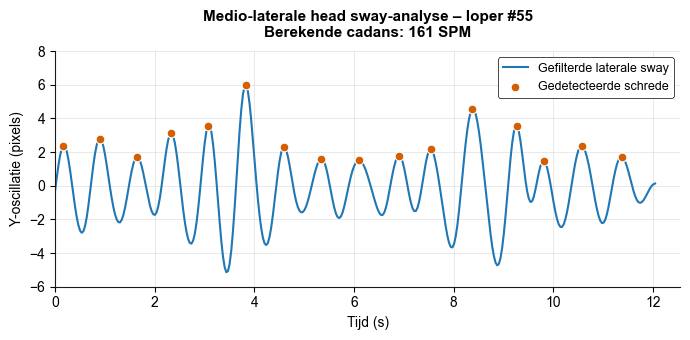

In [9]:
if plot_data:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'Helvetica', 'sans-serif']

    FONT_SIZE_LABELS = 10
    FONT_SIZE_TICKS = 9
    FONT_SIZE_LEGEND = 9
    FONT_SIZE_TITLE = 11

    plt.figure(figsize=(7, 3.5))

    time_stamps = plot_data['time']
    y_smoothed = plot_data['smooth']
    peaks = plot_data['peaks']
    spm = plot_data['spm']

    # Om 0 sec te forceren bij start
    t_start = time_stamps[0]
    time_stamps_zeroed = [t - t_start for t in time_stamps]
    piek_tijden = [time_stamps_zeroed[p] for p in peaks]
    piek_waardes = [y_smoothed[p] for p in peaks]

    plt.plot(time_stamps_zeroed, y_smoothed, label='Gefilterde laterale sway', color='#1f77b4', linewidth=1.5)
    plt.scatter(piek_tijden, piek_waardes, color='#D55E00', s=40, edgecolor='white', linewidth=0.8, label=f'Gedetecteerde schrede', zorder=5)

    plt.title(f"Medio-laterale head sway-analyse – loper #{TARGET_ID_PLOT}\nBerekende cadans: {spm:.0f} SPM", fontsize=FONT_SIZE_TITLE, fontweight='bold', pad=10)
    plt.xlabel("Tijd (s)", fontsize=FONT_SIZE_LABELS)
    plt.ylabel("Y-oscillatie (pixels)", fontsize=FONT_SIZE_LABELS)

    plt.ylim(-6, 8)
    plt.xlim(0, max(time_stamps_zeroed) + 0.5)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#1a1a1a')
    ax.spines['bottom'].set_color('#1a1a1a')
    ax.tick_params(direction='out', top=False, right=False)

    plt.grid(True, which='both', linestyle='-', color='#B0B0B0', linewidth=0.4, alpha=0.5)

    leg = plt.legend(fontsize=FONT_SIZE_LEGEND, loc='upper right', frameon=True, framealpha=1, facecolor='white', edgecolor='black')
    leg.get_frame().set_linewidth(0.5)

    plt.tight_layout()
    plt.show()
else:
    print(f"Loper ID {TARGET_ID_PLOT} was niet gevonden of overleefde de min_track filtering niet in deze run.")